## Import library

In [1]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import keras
import tensorflow

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout, BatchNormalization, Activation

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Load Dataset

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
train_path = f'{HOME}/drive/MyDrive/CatDogClassifyDataset/train'
valid_path =  f'{HOME}/drive/MyDrive/CatDogClassifyDataset/valid'
test_path =  f'{HOME}/drive/MyDrive/CatDogClassifyDataset/test'

dog
cat


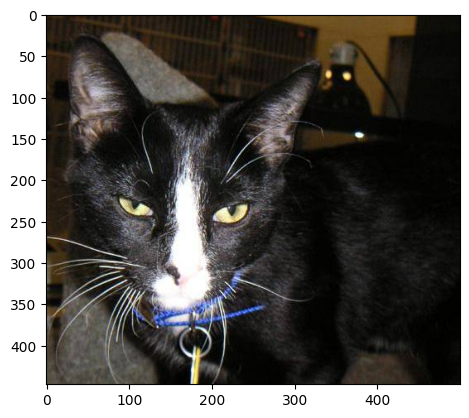

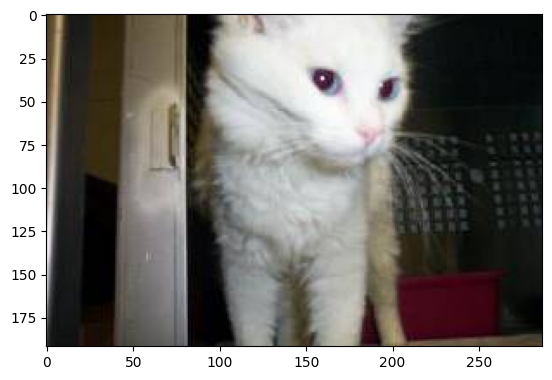

In [5]:
for folder in os.listdir(valid_path):
  sub_path = valid_path + f'/{folder}'
  print(folder)

for i in range(2):
  temp_path = os.listdir(sub_path)[i]
  temp_path = sub_path + '/' + temp_path
  img = mpimg.imread(temp_path)
  implot = plt.imshow(img)
  plt.show()

## Prepare and normalization

In [15]:
batch_size = 32

train_generator = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

test_generator = ImageDataGenerator(rescale=1./255)

train_dataset = train_generator.flow_from_directory(
    directory=train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=True,
    class_mode='categorical'
)

validation_dataset = test_generator.flow_from_directory(
    directory=valid_path,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False,
    class_mode='categorical'
)

test_dataset = test_generator.flow_from_directory(
    directory=test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False,
    class_mode='categorical'
)

Found 17500 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [16]:
IMG_SHAPE = (224,224,3)
num_of_categories = 2

## Model Training

In [17]:
base_model = tensorflow.keras.applications.VGG19(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable=False


x2 = tensorflow.keras.layers.Flatten()(base_model.output)
x2 = tensorflow.keras.layers.Dense(512, activation='relu')(x2)
x2 = tensorflow.keras.layers.Dropout(0.2)(x2)
x2 = tensorflow.keras.layers.Dense(num_of_categories, activation='softmax')(x2)
model = tensorflow.keras.models.Model(base_model.input, x2)


# model = tensorflow.keras.Sequential([
#     base_model,
#     tensorflow.keras.layers.Dense(512, activation='relu'),
#     tensorflow.keras.layers.Dropout(0.2),
#     tensorflow.keras.layers.Dense(num_of_categories, activation='softmax')
# ])

print(model.summary())


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             

 Total params: 32,870,978 (125.39 MB)

 Trainable params: 12,846,594 (49.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

None


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 388ms/step - accuracy: 0.7629 - loss: 0.4833 - val_accuracy: 0.9056 - val_loss: 0.2362
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 93s 467ms/step - accuracy: 0.9053 - loss: 0.2233 - val_accuracy: 0.9154 - val_loss: 0.2061
Epoch 3/20
147/200 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.9216 - loss: 0.1993

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 63s 314ms/step - accuracy: 0.9204 - loss: 0.2006 - val_accuracy: 0.9192 - val_loss: 0.1905
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 101s 367ms/step - accuracy: 0.9173 - loss: 0.2077 - val_accuracy: 0.9196 - val_loss: 0.1883
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 366ms/step - accuracy: 0.9210 - loss: 0.1837 - val_accuracy: 0.9244 - val_loss: 0.1850
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 62s 311ms/step - accuracy: 0.9360 - loss: 0.1526 - val_accuracy: 0.9234 - val_loss: 0.1841
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 412ms/step - accuracy: 0.9275 - loss: 0.1743 - val_accuracy: 0.9216 - val_loss: 0.1869
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 367ms/step - accuracy: 0.9349 - loss: 0.1622 - val_accuracy: 0.9188 - val_loss: 0.1916
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 71s 356ms/step - accuracy: 0.9268 - loss: 0.1683 - val_accuracy: 0.8928 - val_loss: 0.2520
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 109s 367ms/step - accuracy: 0.9366 - loss: 0.1519 - 

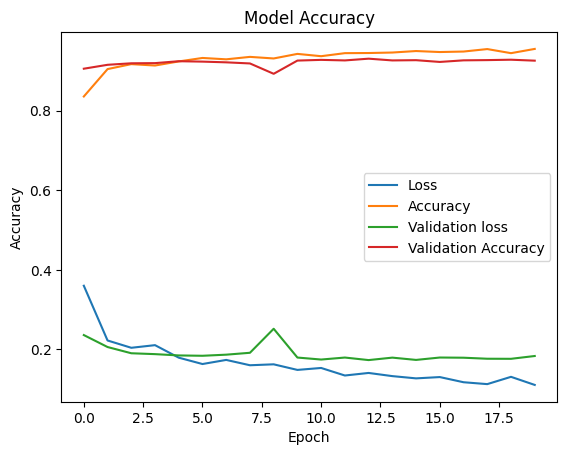

In [19]:
model.compile(optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch=200,
    validation_data=validation_dataset,
    verbose=1
)
model.save('/content/drive/MyDrive/vgg_model.h5')
with open('/content/drive/MyDrive/hist.pkl', 'wb') as file:
    pickle.dump(hist.history, file)
import matplotlib.pyplot as plt

plt.plot(hist.history["loss"])
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_loss"])
plt.plot(hist.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Loss", "Accuracy", "Validation loss", "Validation Accuracy"])
plt.show()

model.save('/content/drive/MyDrive/vgg_model.h5')
with open('/content/drive/MyDrive/hist.pkl', 'wb') as file:
    pickle.dump(hist.history, file)

In [ ]:
model.save('/content/drive/MyDrive/vgg_model.h5')
with open('/content/drive/MyDrive/hist.pkl', 'wb') as file:
    pickle.dump(hist.history, file)

## Model Testing